In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

az.rcParams["stats.ci_prob"] = 0.90

In [2]:
def make_scalarMap(m):
    """Create a Matplotlib `ScalarMappable` so we can use a consistent colormap across both data points and posterior predictive lines. We can use `scalarMap.cmap` to use as a colormap, and `scalarMap.to_rgba(moderator_value)` to grab a colour for a given moderator value."""
    return ScalarMappable(norm=Normalize(vmin=np.min(m), vmax=np.max(m)), cmap="viridis")


def plot_data(x, moderator, y, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1)
    else:
        fig = plt.gcf()

    h = ax.scatter(x, y, c=moderator, cmap=scalarMap.cmap)
    ax.set(xlabel="x", ylabel="y")
    # colourbar for moderator
    cbar = fig.colorbar(h)
    cbar.ax.set_ylabel("moderator")
    return ax


def posterior_prediction_plot(result, x, moderator, m_quantiles, ax=None):
    """Plot posterior predicted `y`"""
    if ax is None:
        fig, ax = plt.subplots(1, 1)

    post = az.extract(result)
    xi = xr.DataArray(np.linspace(np.min(x), np.max(x), 20), dims=["x_plot"])
    m_levels = result.constant_data["m"].quantile(m_quantiles).rename({"quantile": "m_level"})

    for p, m in zip(m_quantiles, m_levels):
        y = post.β0 + post.β1 * xi + post.β2 * xi * m + post.β3 * m
        region = y.quantile([0.025, 0.5, 0.975], dim="sample")
        ax.fill_between(
            xi,
            region.sel(quantile=0.025),
            region.sel(quantile=0.975),
            alpha=0.2,
            color=scalarMap.to_rgba(m),
            edgecolor="w",
        )
        ax.plot(
            xi,
            region.sel(quantile=0.5),
            color=scalarMap.to_rgba(m),
            linewidth=2,
            label=f"{p*100}th percentile of moderator",
        )

    ax.legend(fontsize=9)
    ax.set(xlabel="x", ylabel="y")
    return ax


def plot_moderation_effect(result, m, m_quantiles, ax=None):
    """Spotlight graph"""

    if ax is None:
        fig, ax = plt.subplots(1, 1)

    post = az.extract(result)

    # calculate 95% CI region and median
    xi = xr.DataArray(np.linspace(np.min(m), np.max(m), 20), dims=["x_plot"])
    rate = post.β1 + post.β2 * xi
    region = rate.quantile([0.025, 0.5, 0.975], dim="sample")

    ax.fill_between(
        xi,
        region.sel(quantile=0.025),
        region.sel(quantile=0.975),
        alpha=0.2,
        color="k",
        edgecolor="w",
    )

    ax.plot(xi, region.sel(quantile=0.5), color="k", linewidth=2)

    # plot points at each percentile of m
    percentile_list = np.array(m_quantiles) * 100
    m_levels = np.percentile(m, percentile_list)
    for p, m in zip(percentile_list, m_levels):
        ax.plot(
            m,
            np.mean(post.β1) + np.mean(post.β2) * m,
            "o",
            c=scalarMap.to_rgba(m),
            markersize=10,
            label=f"{p}th percentile of moderator",
        )

    ax.legend(fontsize=9)

    ax.set(
        title="Spotlight graph",
        xlabel="$moderator$",
        ylabel=r"$\beta_1 + \beta_2 \cdot moderator$",
    )


In [3]:
def load_data():
    
    df = pd.read_csv("/Users/vladasverkelis/Documents/Doktorantūra/Straipsnis_1/Context_influance_to_EU_structural_funds/Data/y/lv_tcdf.csv")

    x = df["EUPC"].values
    m = df["ROL"].values
    y = df["FDI"].values
    return (x, y, m)


x, y, m = load_data()

# Make a scalar color map for this dataset (Just for plotting, nothing to do with inference)
scalarMap = make_scalarMap(m)

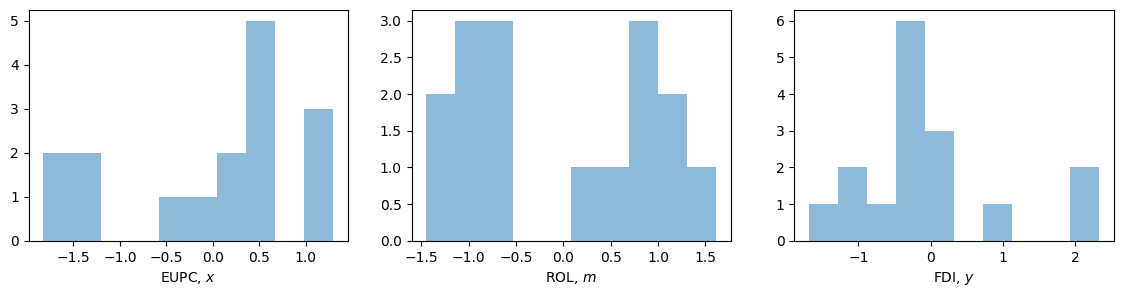

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ax[0].hist(x, alpha=0.5)
ax[0].set(xlabel="EUPC, $x$")

ax[1].hist(m, alpha=0.5)
ax[1].set(xlabel="ROL, $m$")

ax[2].hist(y, alpha=0.5)
ax[2].set(xlabel="FDI, $y$");

In [5]:
def model_factory(x, m, y):
    with pm.Model() as model:
        x = pm.Data("x", x)
        m = pm.Data("m", m)
        # priors
        β0 = pm.Normal("β0", mu=0, sigma=10)
        β1 = pm.Normal("β1", mu=0, sigma=10)
        β2 = pm.Normal("β2", mu=0, sigma=10)
        β3 = pm.Normal("β3", mu=0, sigma=10)
        σ = pm.HalfCauchy("σ", 1)
        # likelihood
        y = pm.Normal("y", mu=β0 + (β1 * x) + (β2 * x * m) + (β3 * m), sigma=σ, observed=y)

    return model

In [6]:
model = model_factory(x, m, y)

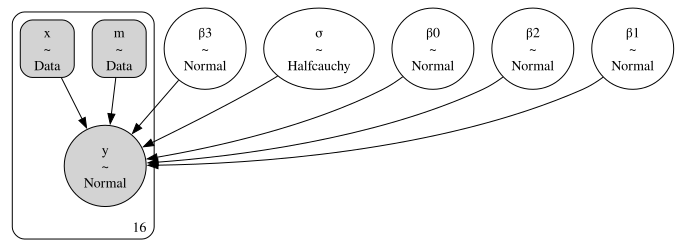

In [7]:
pm.model_to_graphviz(model)

In [8]:
with model:
    result = pm.sample(draws=1000, tune=1000, random_seed=42, nuts={"target_accept": 0.9})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, β2, β3, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


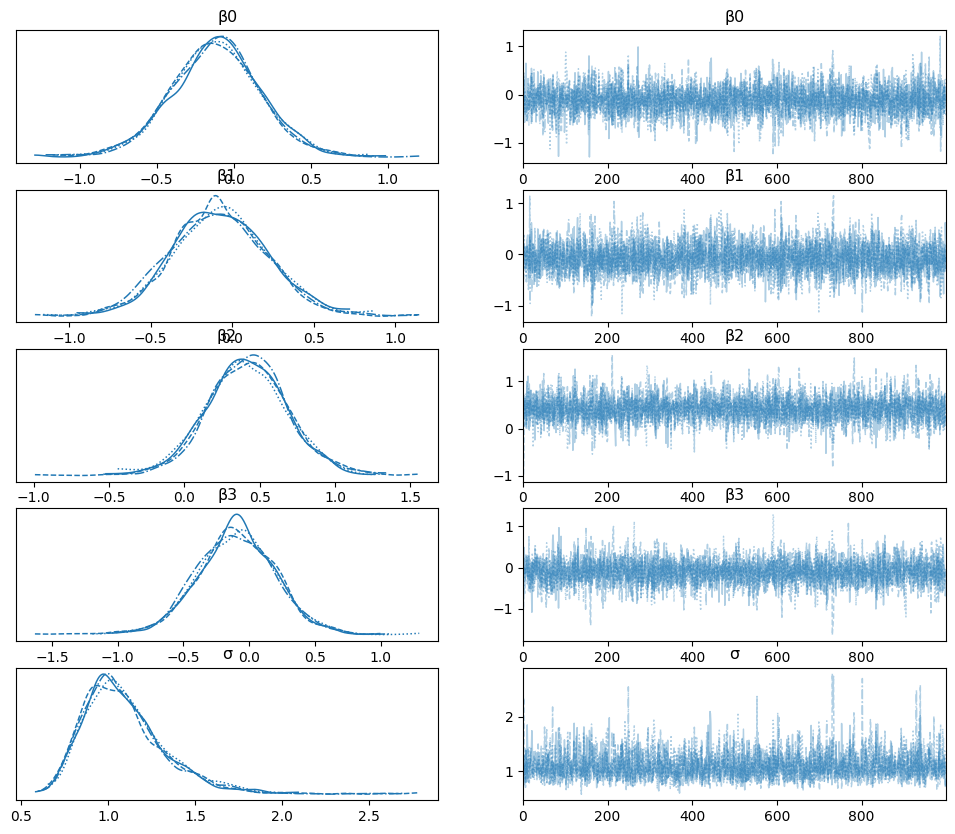

In [9]:
az.plot_trace(result);

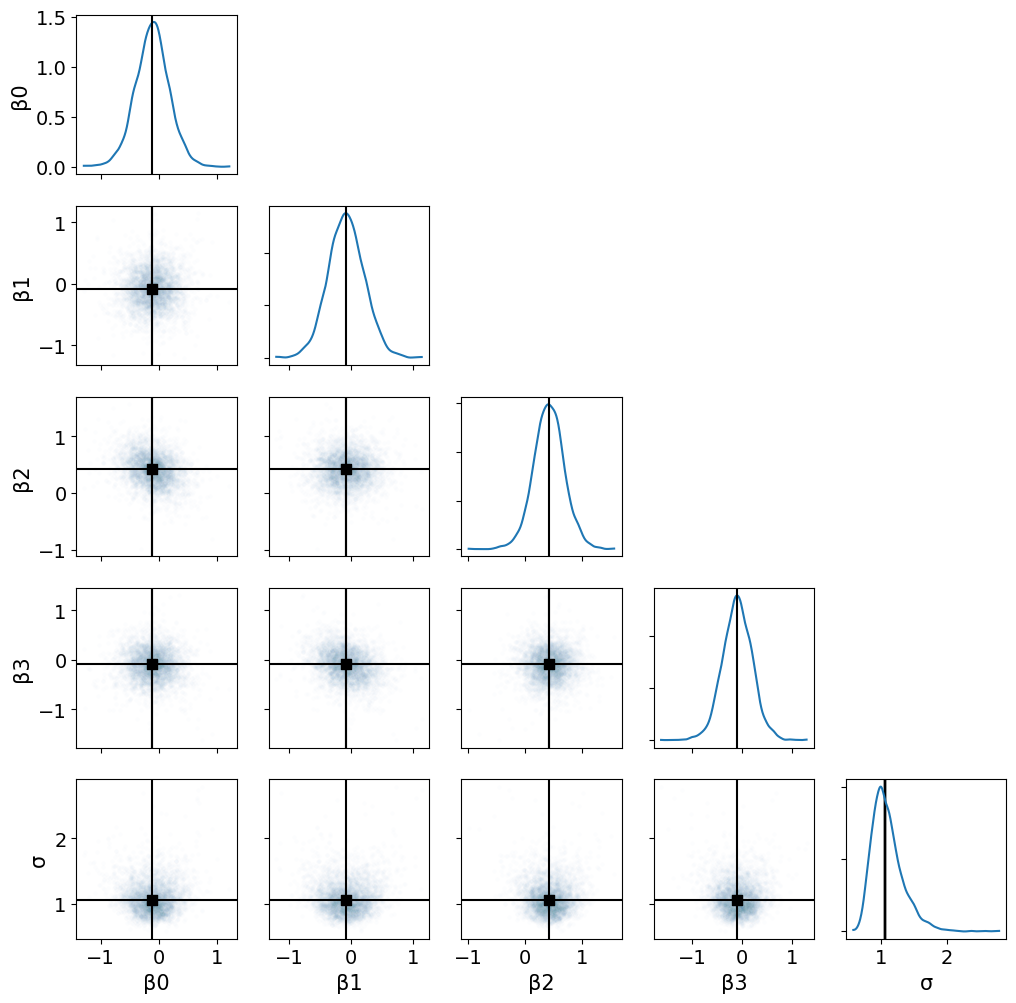

In [10]:
az.plot_pair(
    result,
    marginals=True,
    point_estimate="median",
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.01},
);

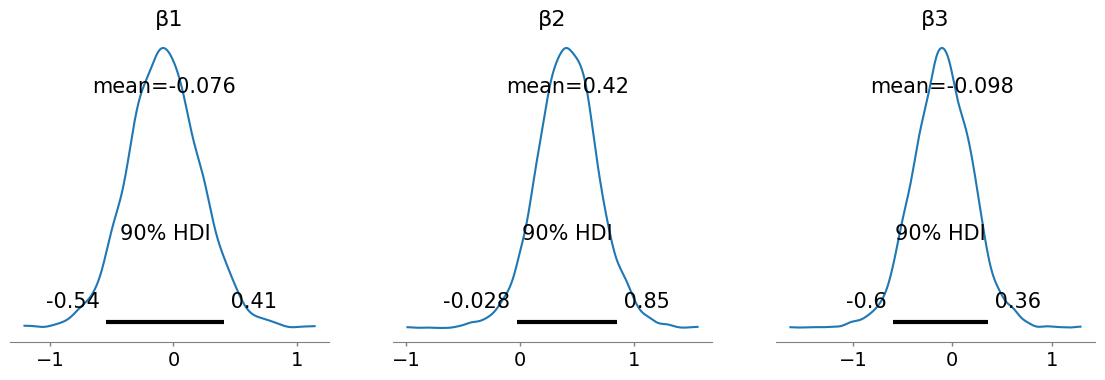

In [11]:
az.plot_posterior(result, var_names=["β1", "β2", "β3"], figsize=(14, 4));

In [12]:
m_quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]

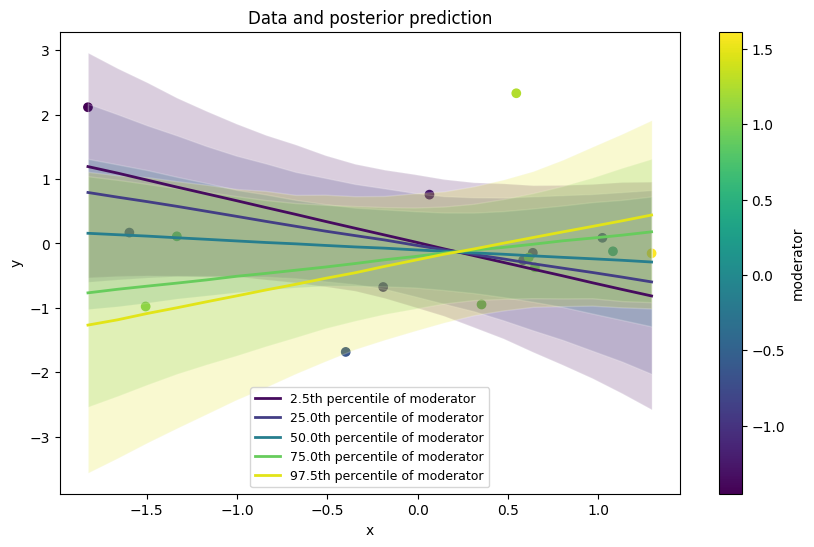

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plot_data(x, m, y, ax=ax)
posterior_prediction_plot(result, x, m, m_quantiles, ax=ax)
ax.set_title("Data and posterior prediction");

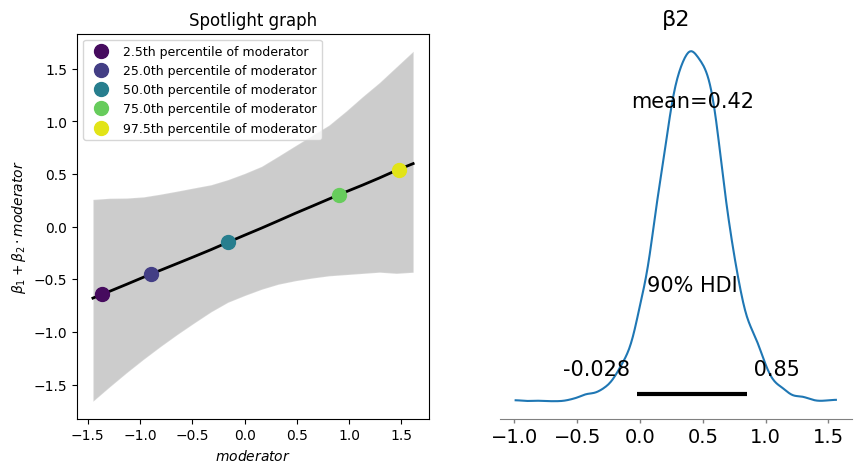

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_moderation_effect(result, m, m_quantiles, ax[0])
az.plot_posterior(result, var_names="β2", ax=ax[1]);

In [15]:
def load_data():
    
    df = pd.read_csv("/Users/vladasverkelis/Documents/Doktorantūra/Straipsnis_1/Context_influance_to_EU_structural_funds/Data/y/lv_tcdf.csv")

    x = df["EUPC"].values
    m = df["GE"].values
    y = df["FDI"].values
    return (x, y, m)


x, y, m = load_data()

# Make a scalar color map for this dataset (Just for plotting, nothing to do with inference)
scalarMap = make_scalarMap(m)

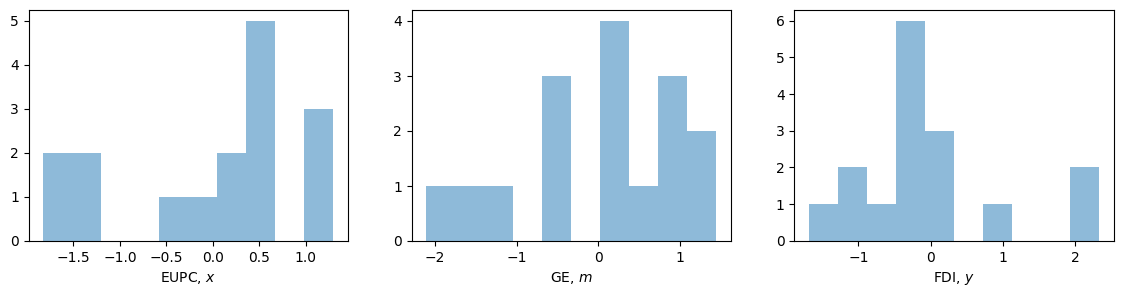

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ax[0].hist(x, alpha=0.5)
ax[0].set(xlabel="EUPC, $x$")

ax[1].hist(m, alpha=0.5)
ax[1].set(xlabel="GE, $m$")

ax[2].hist(y, alpha=0.5)
ax[2].set(xlabel="FDI, $y$");

In [17]:
def model_factory(x, m, y):
    with pm.Model() as model:
        x = pm.Data("x", x)
        m = pm.Data("m", m)
        # priors
        β0 = pm.Normal("β0", mu=0, sigma=10)
        β1 = pm.Normal("β1", mu=0, sigma=10)
        β2 = pm.Normal("β2", mu=0, sigma=10)
        β3 = pm.Normal("β3", mu=0, sigma=10)
        σ = pm.HalfCauchy("σ", 1)
        # likelihood
        y = pm.Normal("y", mu=β0 + (β1 * x) + (β2 * x * m) + (β3 * m), sigma=σ, observed=y)

    return model

In [18]:
model = model_factory(x, m, y)

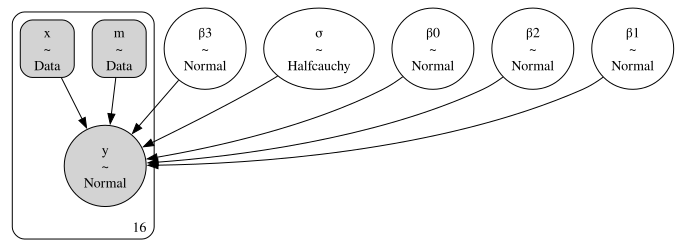

In [19]:
pm.model_to_graphviz(model)

In [20]:
with model:
    result = pm.sample(draws=1000, tune=1000, random_seed=42, nuts={"target_accept": 0.9})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, β2, β3, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


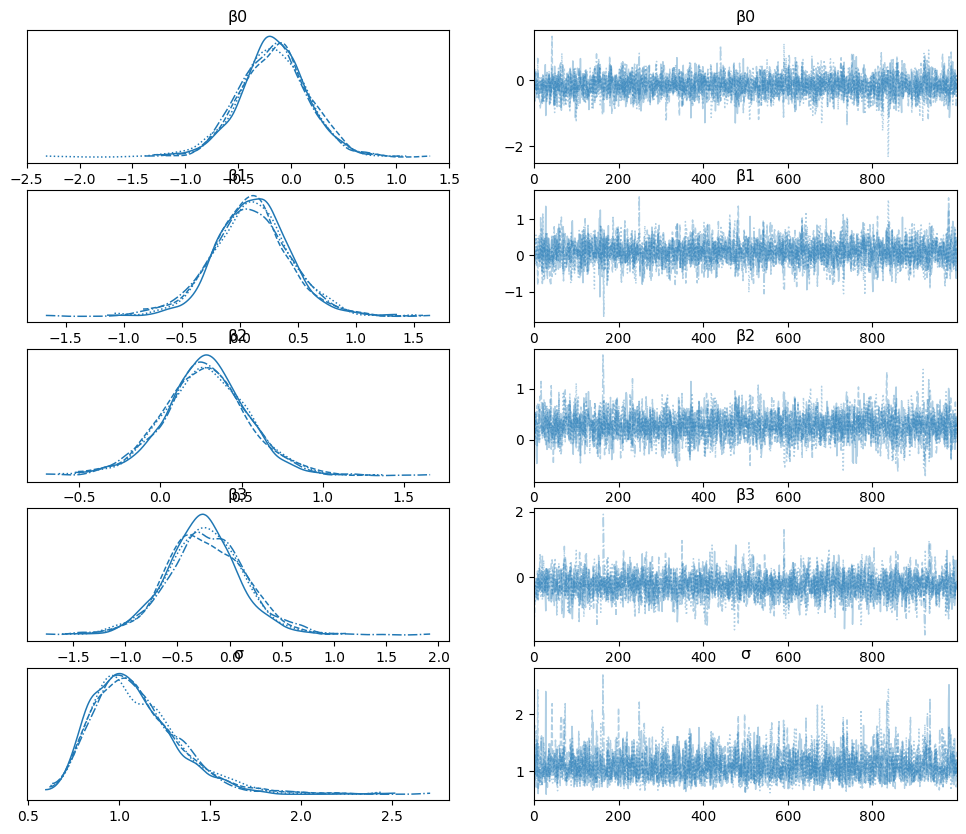

In [21]:
az.plot_trace(result);

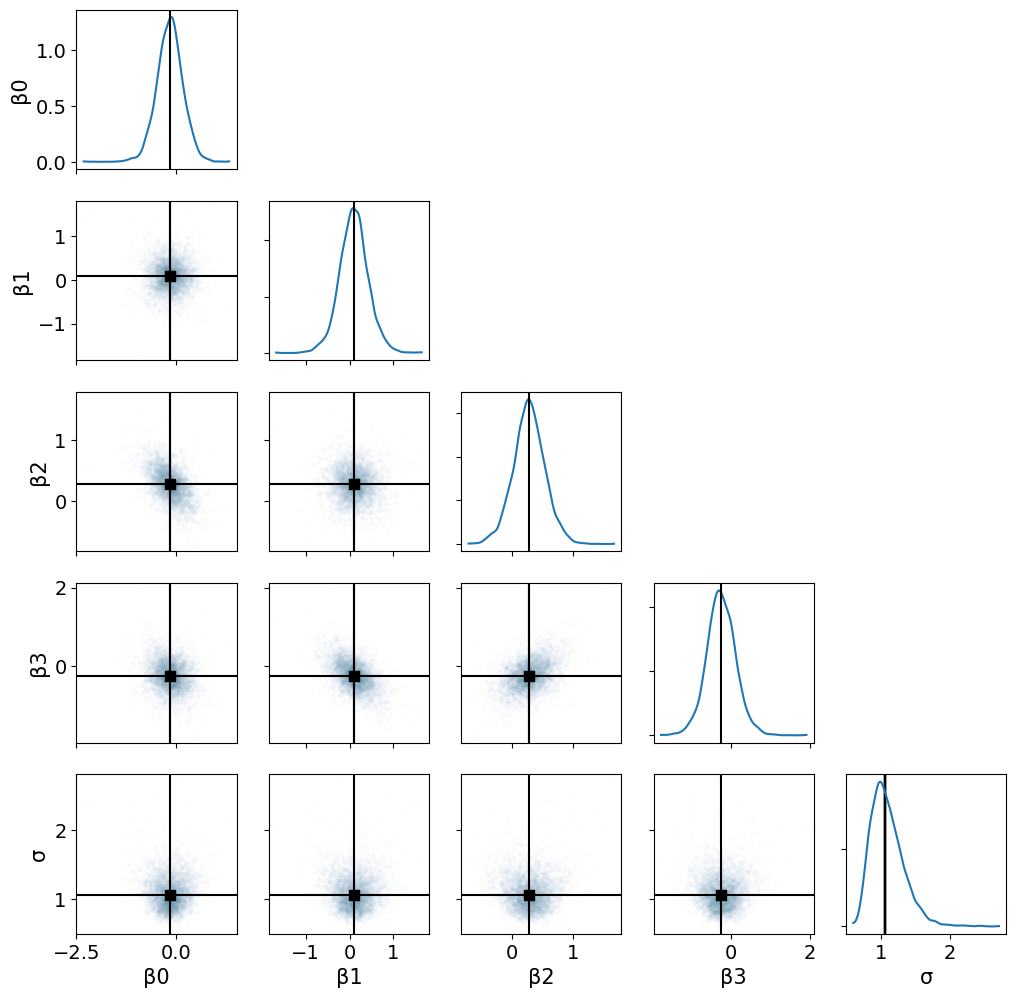

In [22]:
az.plot_pair(
    result,
    marginals=True,
    point_estimate="median",
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.01},
);

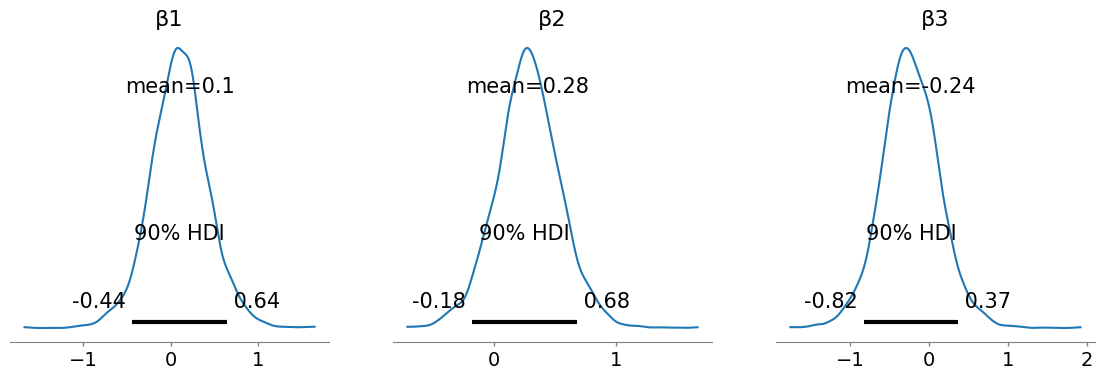

In [23]:
az.plot_posterior(result, var_names=["β1", "β2", "β3"], figsize=(14, 4));

In [24]:
m_quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]

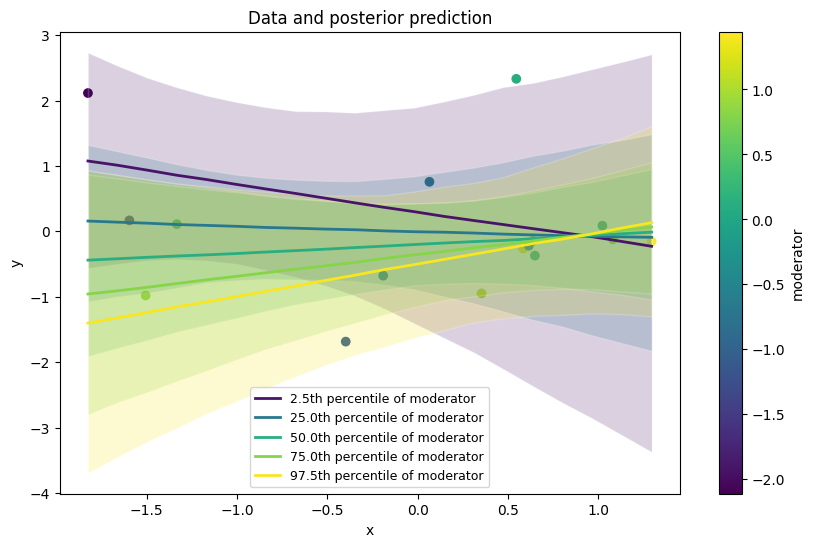

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plot_data(x, m, y, ax=ax)
posterior_prediction_plot(result, x, m, m_quantiles, ax=ax)
ax.set_title("Data and posterior prediction");

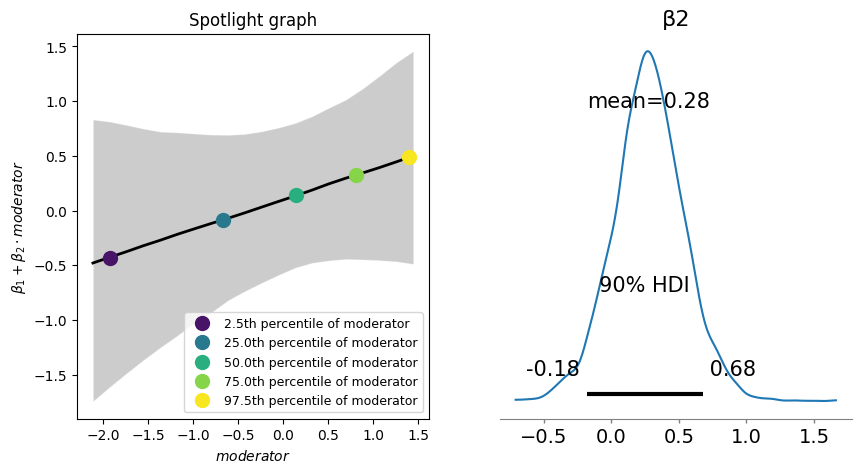

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_moderation_effect(result, m, m_quantiles, ax[0])
az.plot_posterior(result, var_names="β2", ax=ax[1]);

In [27]:
def load_data():
    
    df = pd.read_csv("/Users/vladasverkelis/Documents/Doktorantūra/Straipsnis_1/Context_influance_to_EU_structural_funds/Data/y/lv_tcdf.csv")

    x = df["EUPC"].values
    m = df["COC"].values
    y = df["FDI"].values
    return (x, y, m)


x, y, m = load_data()

# Make a scalar color map for this dataset (Just for plotting, nothing to do with inference)
scalarMap = make_scalarMap(m)

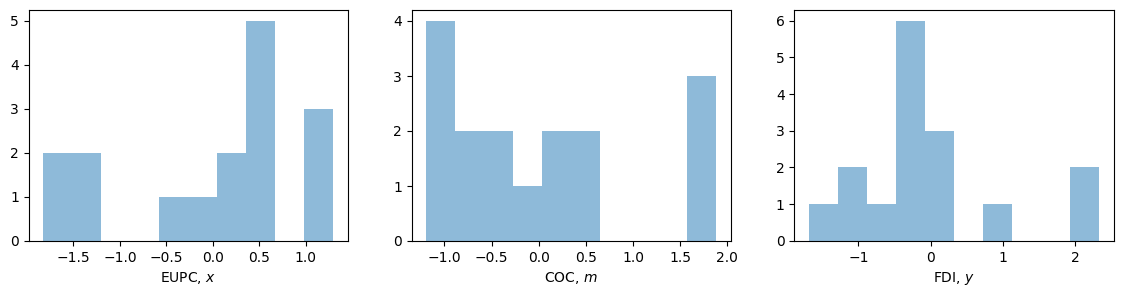

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ax[0].hist(x, alpha=0.5)
ax[0].set(xlabel="EUPC, $x$")

ax[1].hist(m, alpha=0.5)
ax[1].set(xlabel="COC, $m$")

ax[2].hist(y, alpha=0.5)
ax[2].set(xlabel="FDI, $y$");

In [29]:
def model_factory(x, m, y):
    with pm.Model() as model:
        x = pm.Data("x", x)
        m = pm.Data("m", m)
        # priors
        β0 = pm.Normal("β0", mu=0, sigma=10)
        β1 = pm.Normal("β1", mu=0, sigma=10)
        β2 = pm.Normal("β2", mu=0, sigma=10)
        β3 = pm.Normal("β3", mu=0, sigma=10)
        σ = pm.HalfCauchy("σ", 1)
        # likelihood
        y = pm.Normal("y", mu=β0 + (β1 * x) + (β2 * x * m) + (β3 * m), sigma=σ, observed=y)

    return model

In [30]:
model = model_factory(x, m, y)

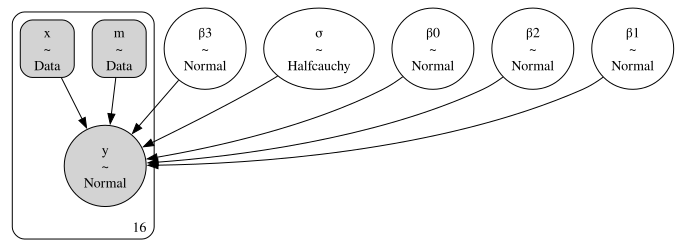

In [31]:
pm.model_to_graphviz(model)

In [32]:
with model:
    result = pm.sample(draws=1000, tune=1000, random_seed=42, nuts={"target_accept": 0.9})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, β2, β3, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


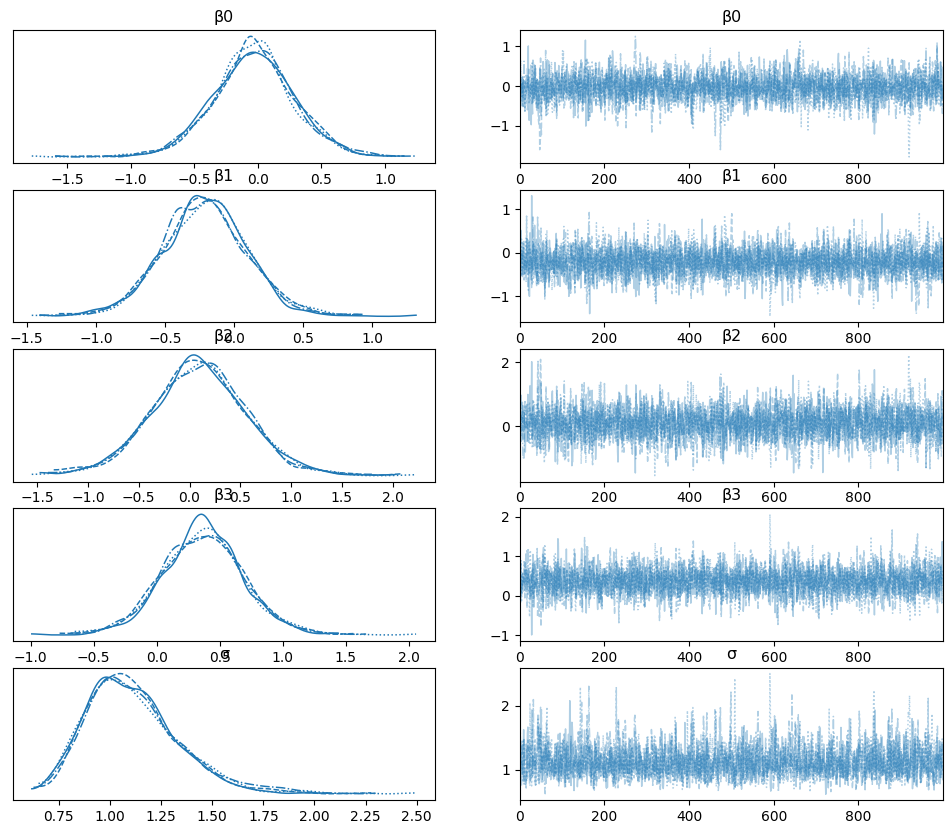

In [33]:
az.plot_trace(result);

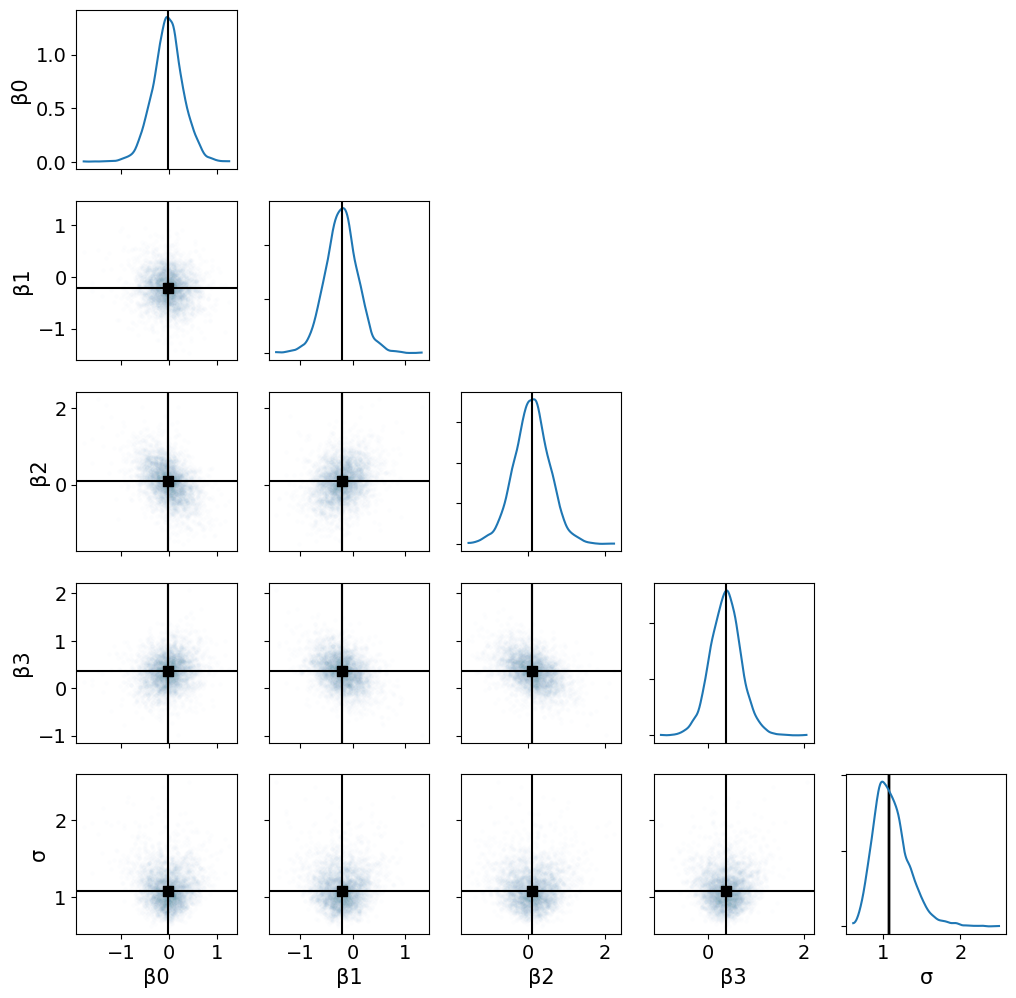

In [34]:
az.plot_pair(
    result,
    marginals=True,
    point_estimate="median",
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.01},
);

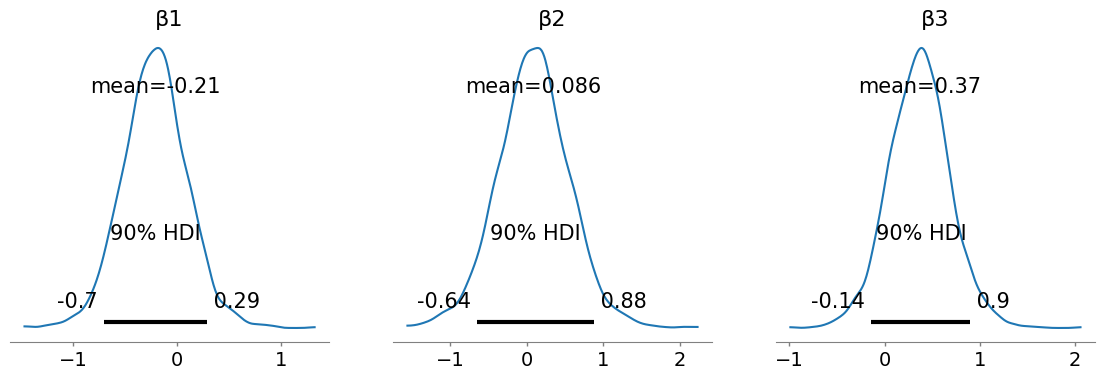

In [35]:
az.plot_posterior(result, var_names=["β1", "β2", "β3"], figsize=(14, 4));

In [36]:
m_quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]

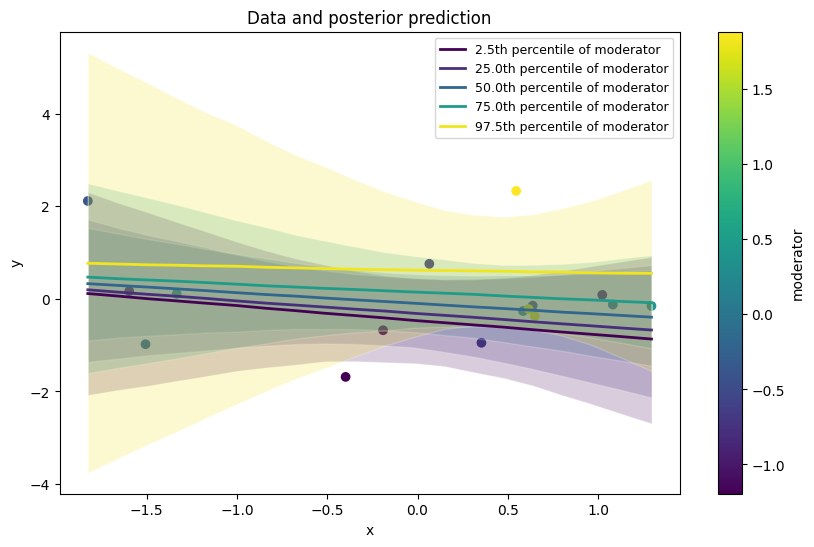

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plot_data(x, m, y, ax=ax)
posterior_prediction_plot(result, x, m, m_quantiles, ax=ax)
ax.set_title("Data and posterior prediction");

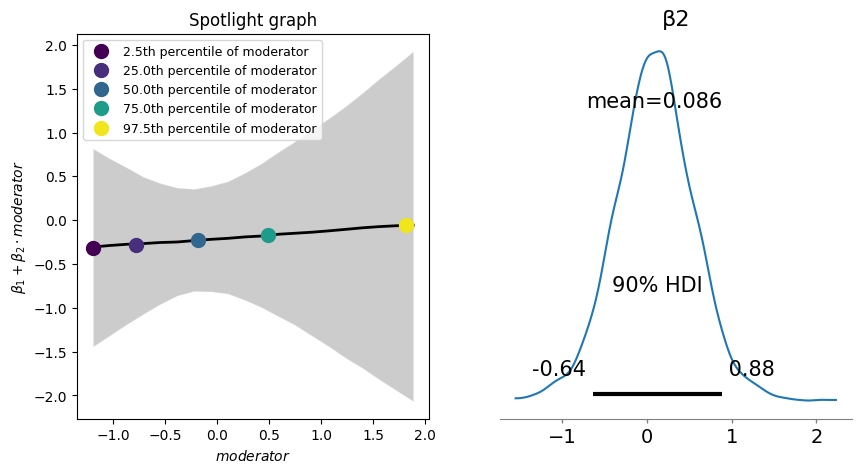

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_moderation_effect(result, m, m_quantiles, ax[0])
az.plot_posterior(result, var_names="β2", ax=ax[1]);

In [39]:
def load_data():
    
    df = pd.read_csv("/Users/vladasverkelis/Documents/Doktorantūra/Straipsnis_1/Context_influance_to_EU_structural_funds/Data/y/lv_tcdf.csv")

    x = df["EUPC"].values
    m = df["RQ"].values
    y = df["FDI"].values
    return (x, y, m)


x, y, m = load_data()

# Make a scalar color map for this dataset (Just for plotting, nothing to do with inference)
scalarMap = make_scalarMap(m)

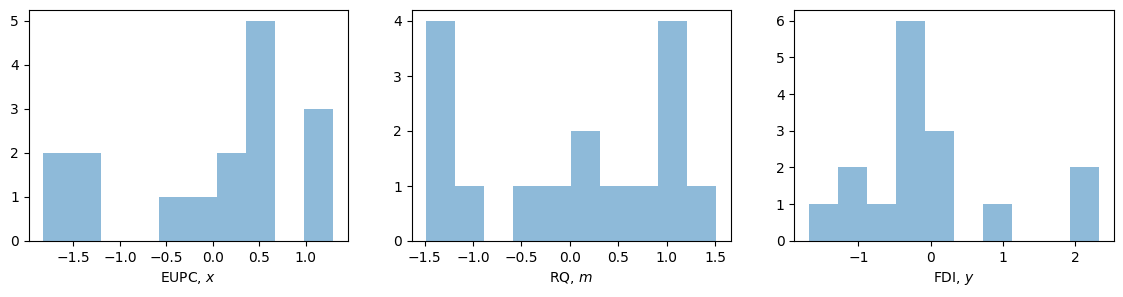

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ax[0].hist(x, alpha=0.5)
ax[0].set(xlabel="EUPC, $x$")

ax[1].hist(m, alpha=0.5)
ax[1].set(xlabel="RQ, $m$")

ax[2].hist(y, alpha=0.5)
ax[2].set(xlabel="FDI, $y$");

In [41]:
def model_factory(x, m, y):
    with pm.Model() as model:
        x = pm.Data("x", x)
        m = pm.Data("m", m)
        # priors
        β0 = pm.Normal("β0", mu=0, sigma=10)
        β1 = pm.Normal("β1", mu=0, sigma=10)
        β2 = pm.Normal("β2", mu=0, sigma=10)
        β3 = pm.Normal("β3", mu=0, sigma=10)
        σ = pm.HalfCauchy("σ", 1)
        # likelihood
        y = pm.Normal("y", mu=β0 + (β1 * x) + (β2 * x * m) + (β3 * m), sigma=σ, observed=y)

    return model

In [42]:
model = model_factory(x, m, y)

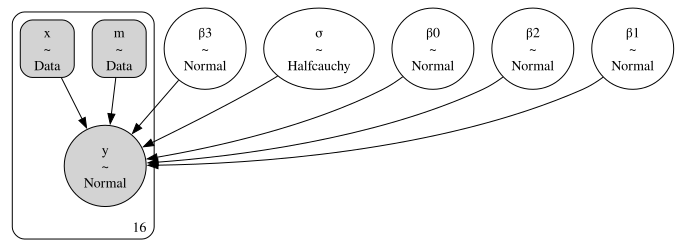

In [43]:
pm.model_to_graphviz(model)

In [44]:
with model:
    result = pm.sample(draws=1000, tune=1000, random_seed=42, nuts={"target_accept": 0.9})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, β2, β3, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


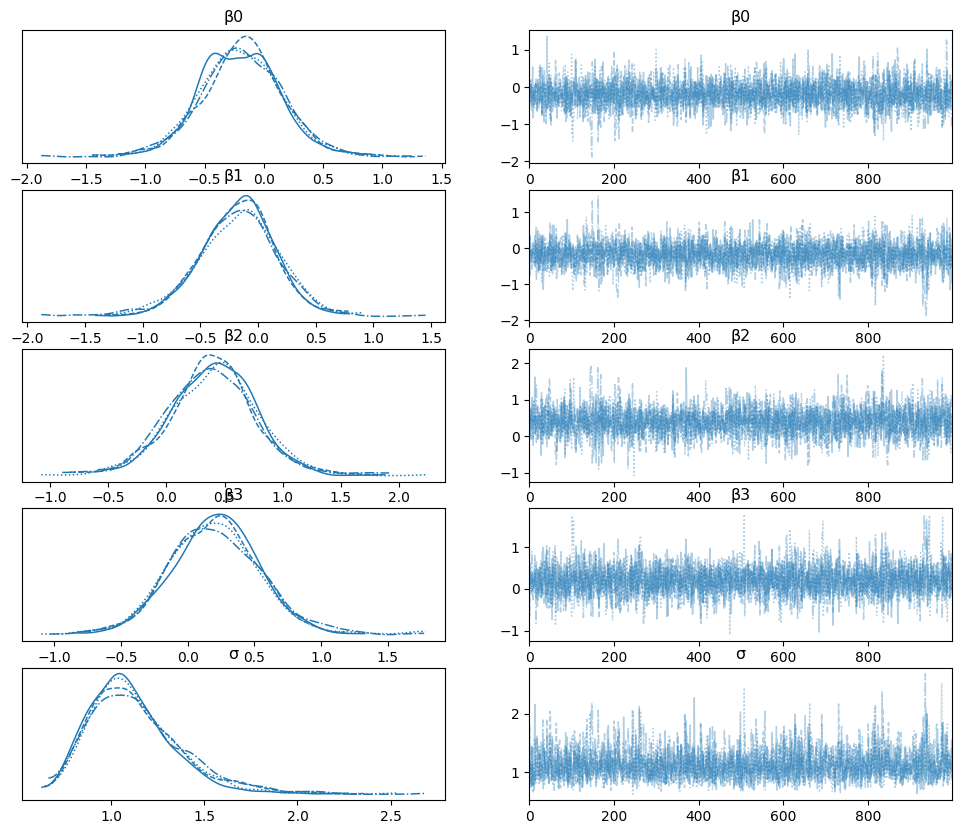

In [45]:
az.plot_trace(result);

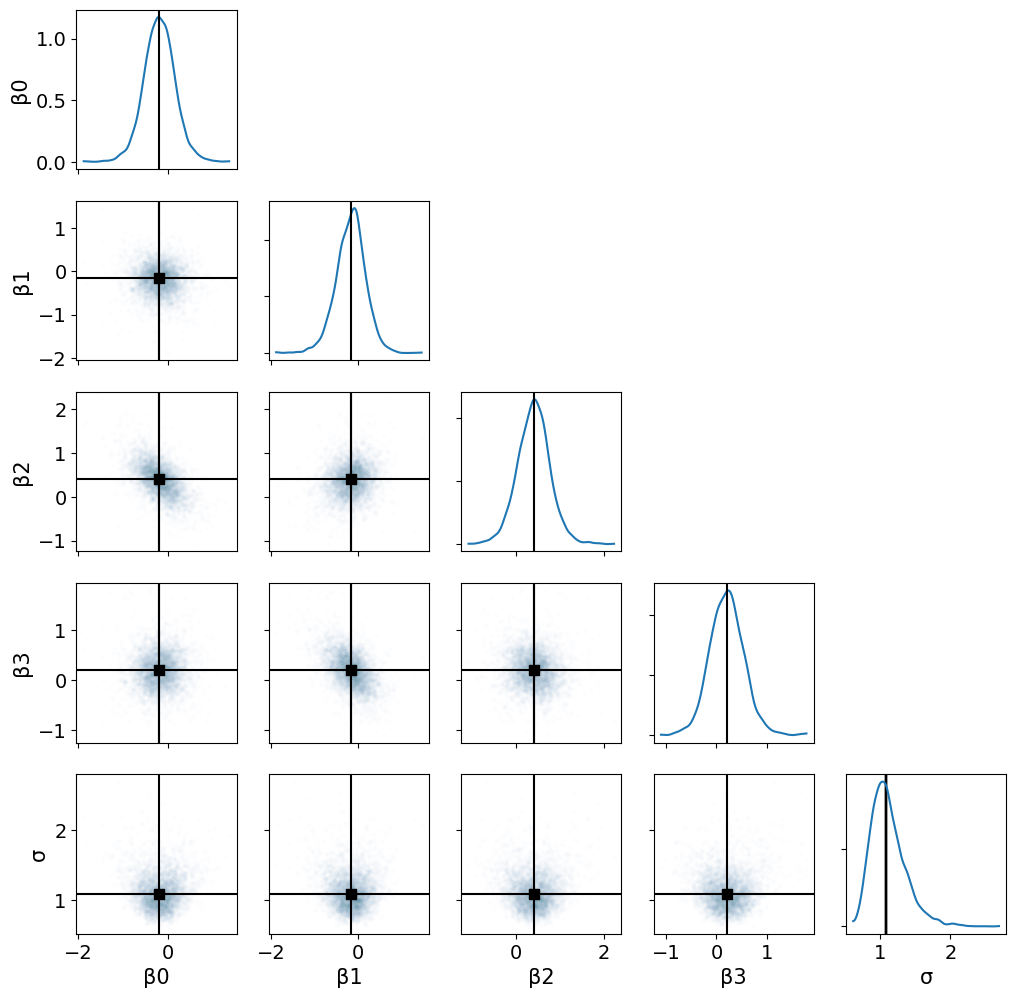

In [46]:
az.plot_pair(
    result,
    marginals=True,
    point_estimate="median",
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.01},
);

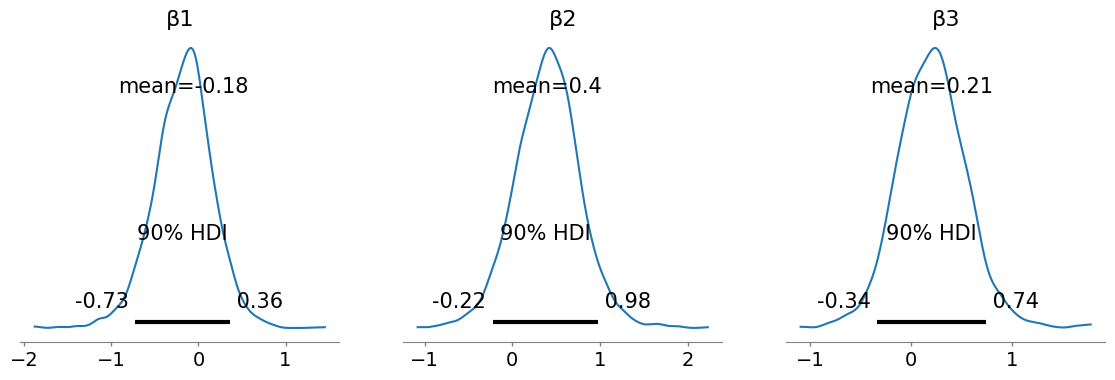

In [47]:
az.plot_posterior(result, var_names=["β1", "β2", "β3"], figsize=(14, 4));

In [48]:
m_quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]

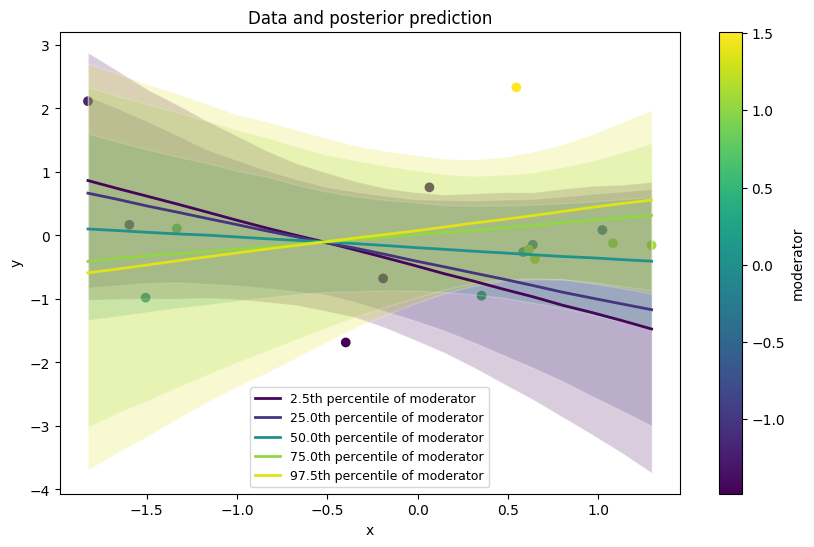

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plot_data(x, m, y, ax=ax)
posterior_prediction_plot(result, x, m, m_quantiles, ax=ax)
ax.set_title("Data and posterior prediction");

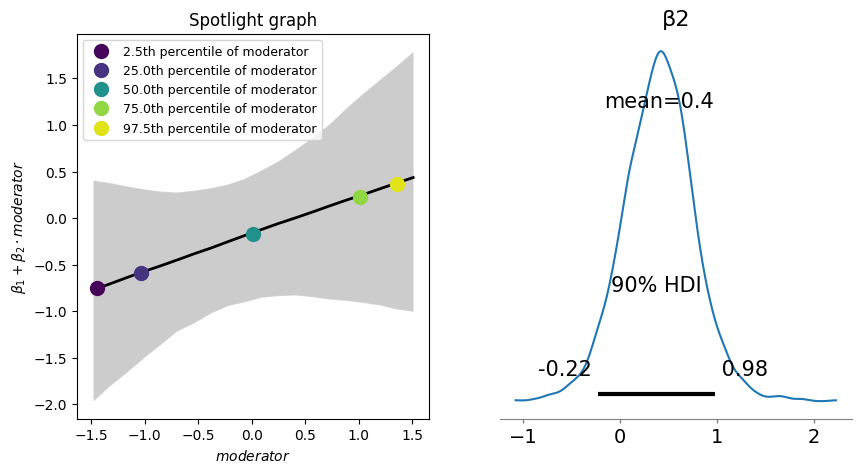

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_moderation_effect(result, m, m_quantiles, ax[0])
az.plot_posterior(result, var_names="β2", ax=ax[1]);

In [51]:
def load_data():
    
    df = pd.read_csv("/Users/vladasverkelis/Documents/Doktorantūra/Straipsnis_1/Context_influance_to_EU_structural_funds/Data/y/lv_tcdf.csv")

    x = df["EUPC"].values
    m = df["SSB"].values
    y = df["FDI"].values
    return (x, y, m)


x, y, m = load_data()

# Make a scalar color map for this dataset (Just for plotting, nothing to do with inference)
scalarMap = make_scalarMap(m)

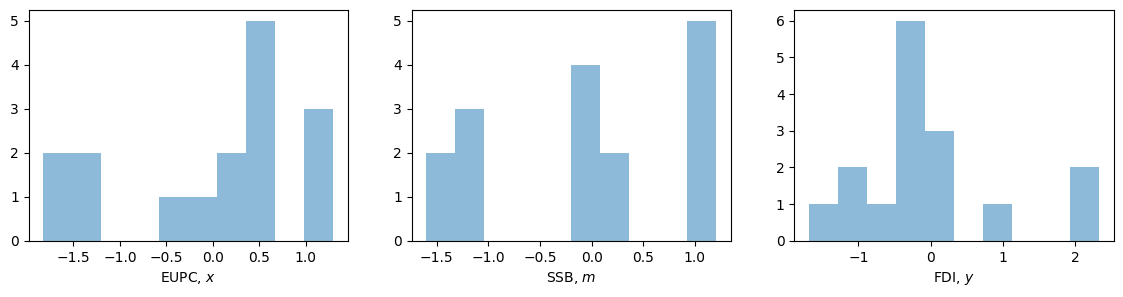

In [52]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ax[0].hist(x, alpha=0.5)
ax[0].set(xlabel="EUPC, $x$")

ax[1].hist(m, alpha=0.5)
ax[1].set(xlabel="SSB, $m$")

ax[2].hist(y, alpha=0.5)
ax[2].set(xlabel="FDI, $y$");

In [53]:
def model_factory(x, m, y):
    with pm.Model() as model:
        x = pm.Data("x", x)
        m = pm.Data("m", m)
        # priors
        β0 = pm.Normal("β0", mu=0, sigma=10)
        β1 = pm.Normal("β1", mu=0, sigma=10)
        β2 = pm.Normal("β2", mu=0, sigma=10)
        β3 = pm.Normal("β3", mu=0, sigma=10)
        σ = pm.HalfCauchy("σ", 1)
        # likelihood
        y = pm.Normal("y", mu=β0 + (β1 * x) + (β2 * x * m) + (β3 * m), sigma=σ, observed=y)

    return model

In [54]:
model = model_factory(x, m, y)

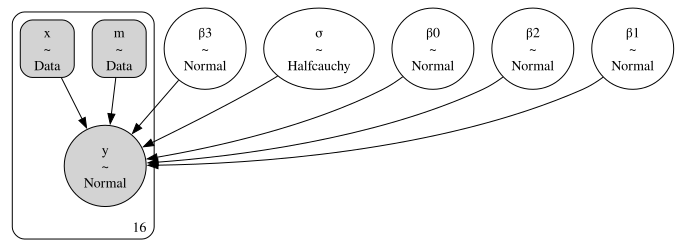

In [55]:
pm.model_to_graphviz(model)

In [56]:
with model:
    result = pm.sample(draws=1000, tune=1000, random_seed=42, nuts={"target_accept": 0.9})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, β2, β3, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


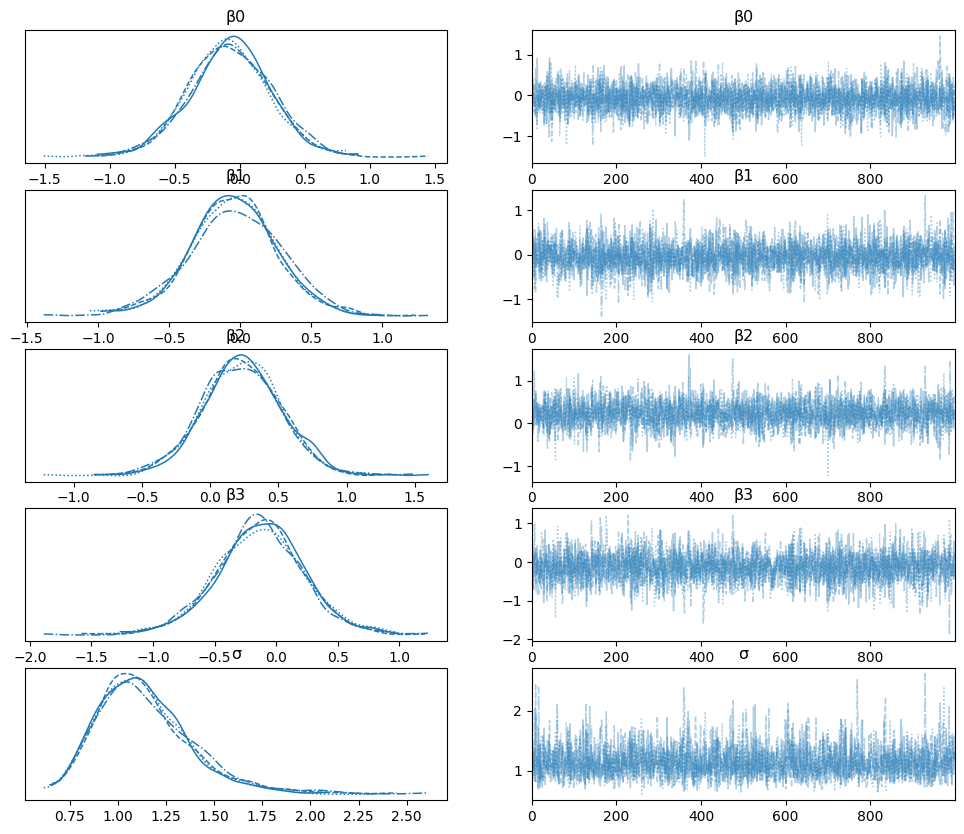

In [57]:
az.plot_trace(result);

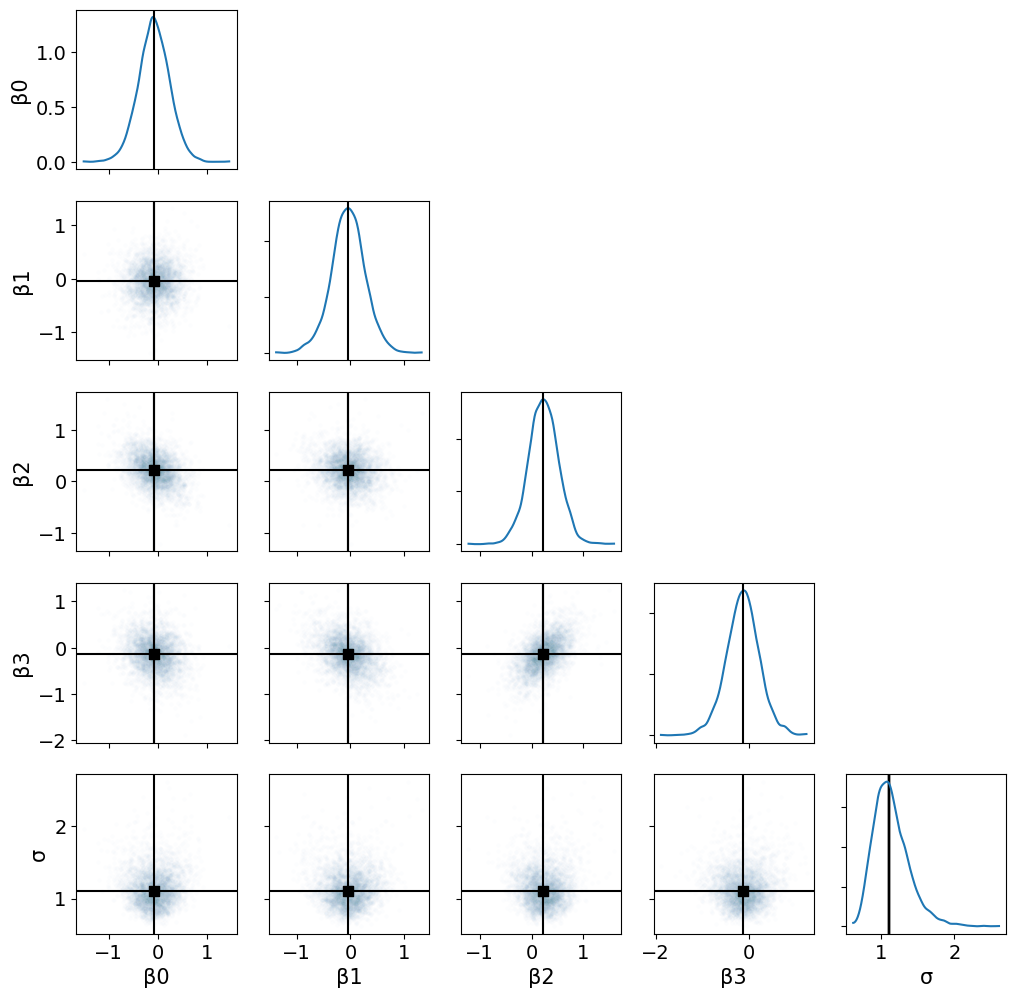

In [58]:
az.plot_pair(
    result,
    marginals=True,
    point_estimate="median",
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.01},
);

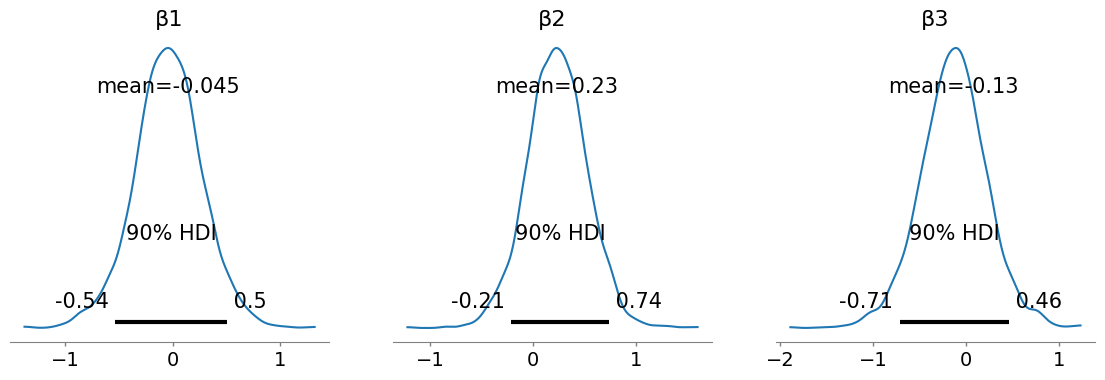

In [59]:
az.plot_posterior(result, var_names=["β1", "β2", "β3"], figsize=(14, 4));

In [60]:
m_quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]

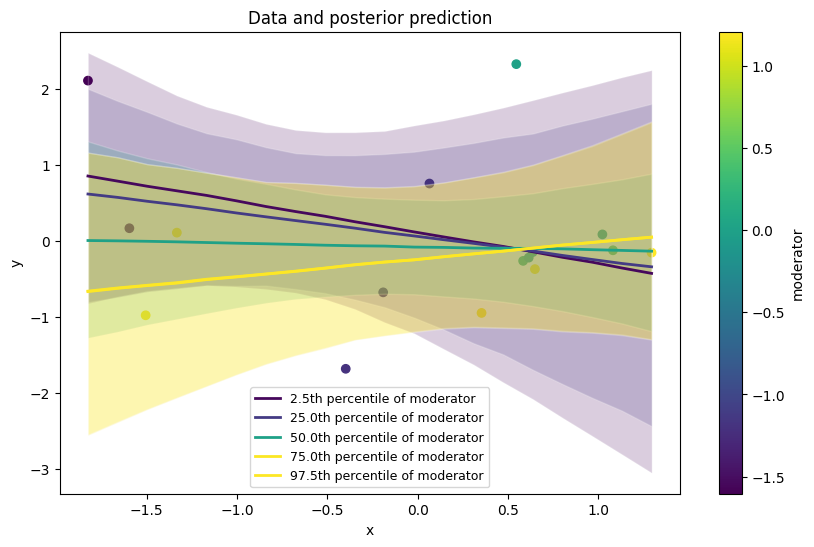

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plot_data(x, m, y, ax=ax)
posterior_prediction_plot(result, x, m, m_quantiles, ax=ax)
ax.set_title("Data and posterior prediction");

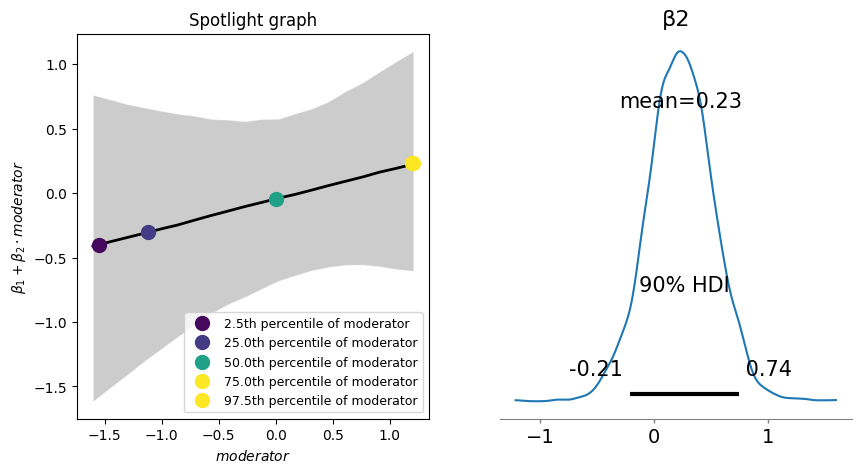

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_moderation_effect(result, m, m_quantiles, ax[0])
az.plot_posterior(result, var_names="β2", ax=ax[1]);

In [63]:
def load_data():
    
    df = pd.read_csv("/Users/vladasverkelis/Documents/Doktorantūra/Straipsnis_1/Context_influance_to_EU_structural_funds/Data/y/lv_tcdf.csv")

    x = df["EUPC"].values
    m = df["PT"].values
    y = df["FDI"].values
    return (x, y, m)


x, y, m = load_data()

# Make a scalar color map for this dataset (Just for plotting, nothing to do with inference)
scalarMap = make_scalarMap(m)

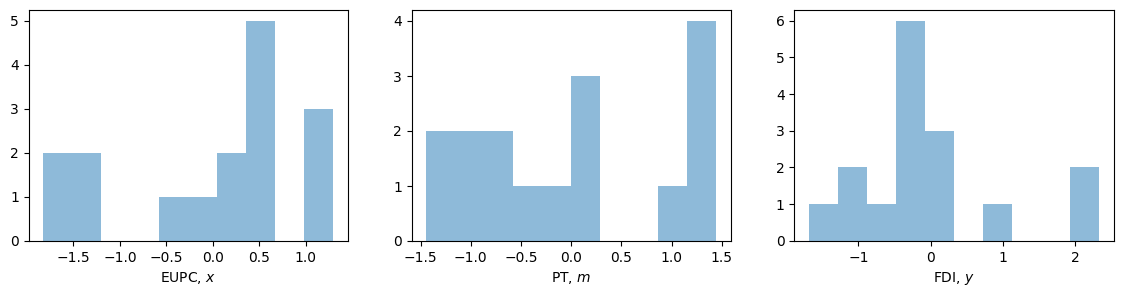

In [64]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

ax[0].hist(x, alpha=0.5)
ax[0].set(xlabel="EUPC, $x$")

ax[1].hist(m, alpha=0.5)
ax[1].set(xlabel="PT, $m$")

ax[2].hist(y, alpha=0.5)
ax[2].set(xlabel="FDI, $y$");

In [65]:
def model_factory(x, m, y):
    with pm.Model() as model:
        x = pm.Data("x", x)
        m = pm.Data("m", m)
        # priors
        β0 = pm.Normal("β0", mu=0, sigma=10)
        β1 = pm.Normal("β1", mu=0, sigma=10)
        β2 = pm.Normal("β2", mu=0, sigma=10)
        β3 = pm.Normal("β3", mu=0, sigma=10)
        σ = pm.HalfCauchy("σ", 1)
        # likelihood
        y = pm.Normal("y", mu=β0 + (β1 * x) + (β2 * x * m) + (β3 * m), sigma=σ, observed=y)

    return model

In [66]:
model = model_factory(x, m, y)

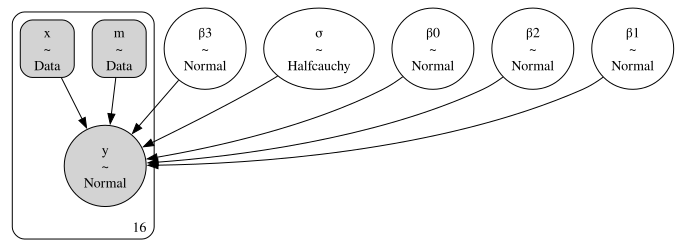

In [67]:
pm.model_to_graphviz(model)

In [68]:
with model:
    result = pm.sample(draws=1000, tune=1000, random_seed=42, nuts={"target_accept": 0.9})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, β2, β3, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


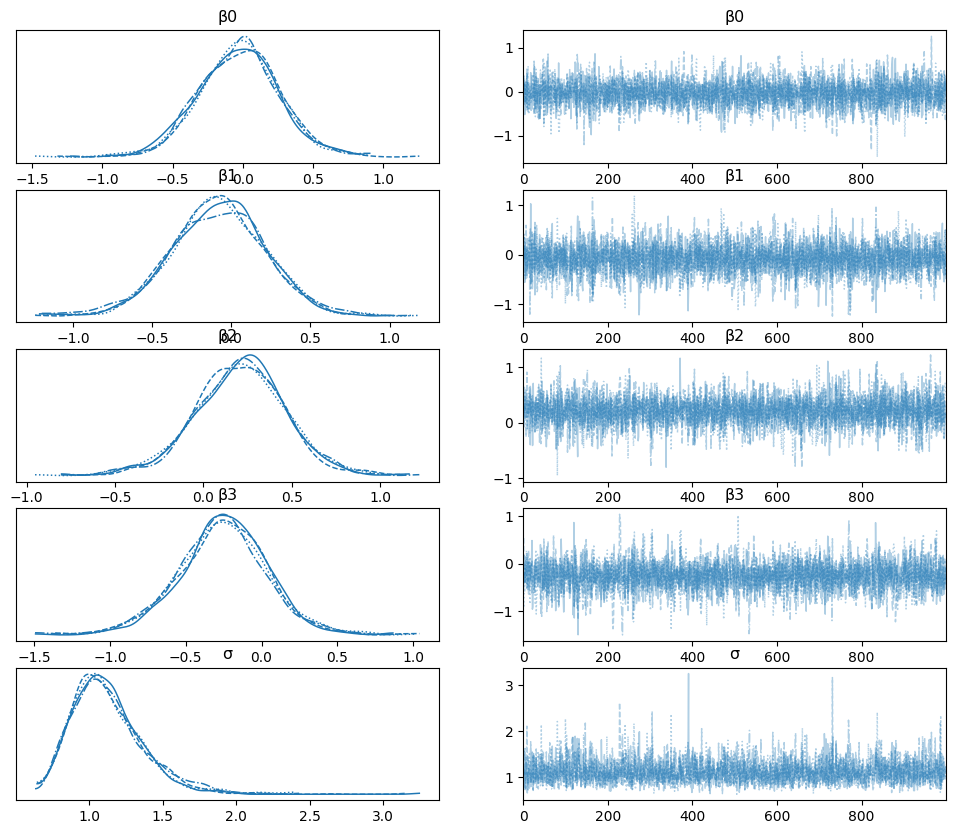

In [69]:
az.plot_trace(result);

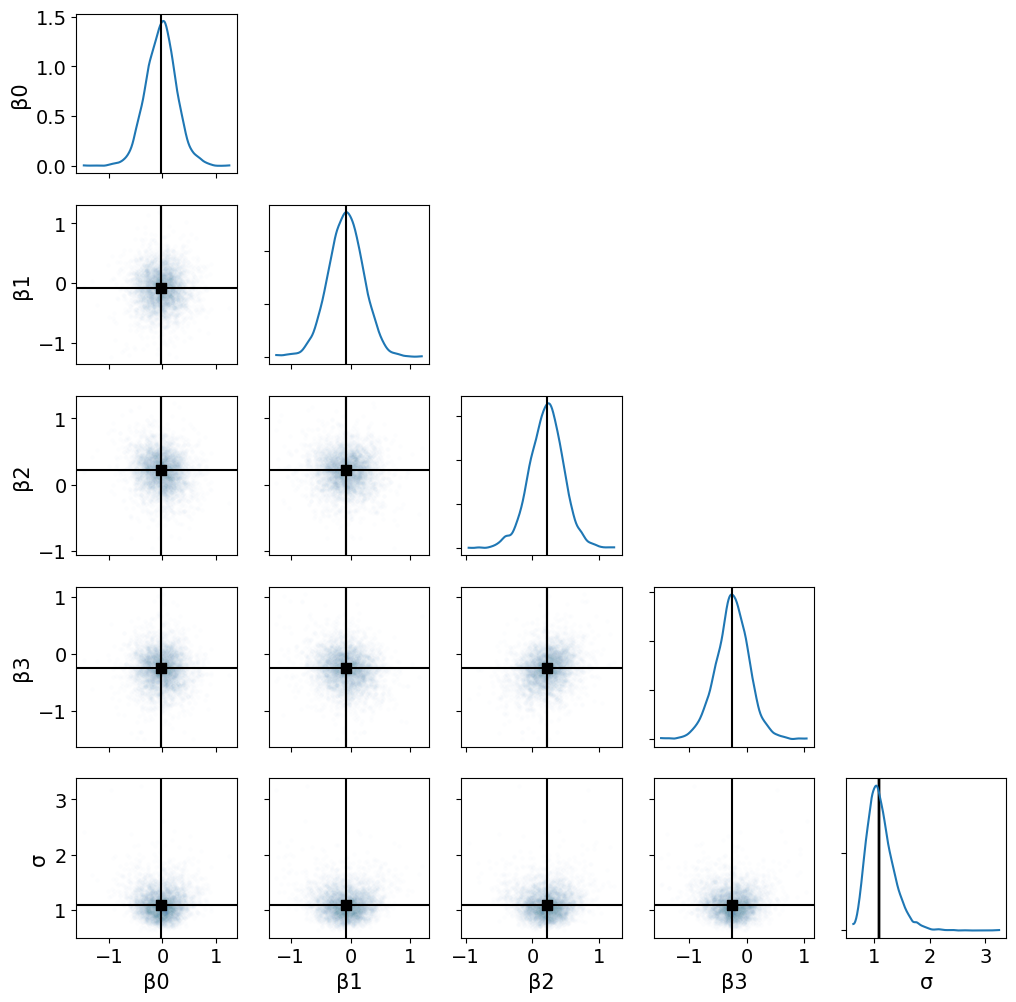

In [70]:
az.plot_pair(
    result,
    marginals=True,
    point_estimate="median",
    figsize=(12, 12),
    scatter_kwargs={"alpha": 0.01},
);

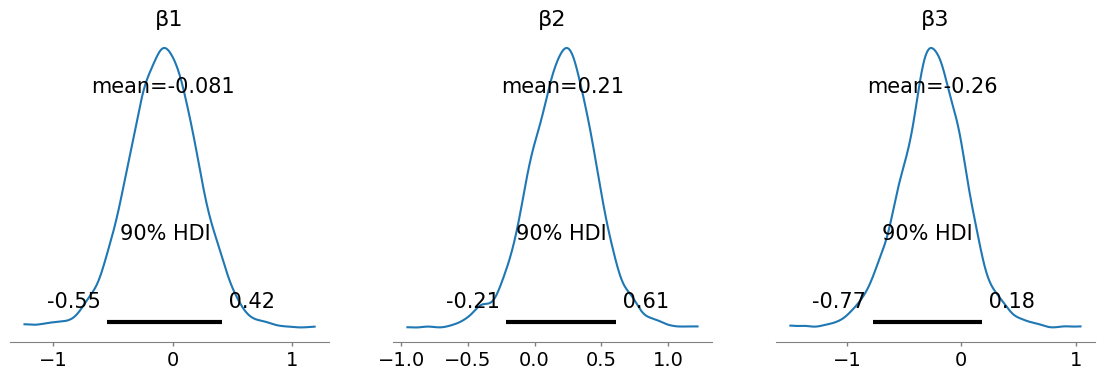

In [71]:
az.plot_posterior(result, var_names=["β1", "β2", "β3"], figsize=(14, 4));

In [72]:
m_quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]

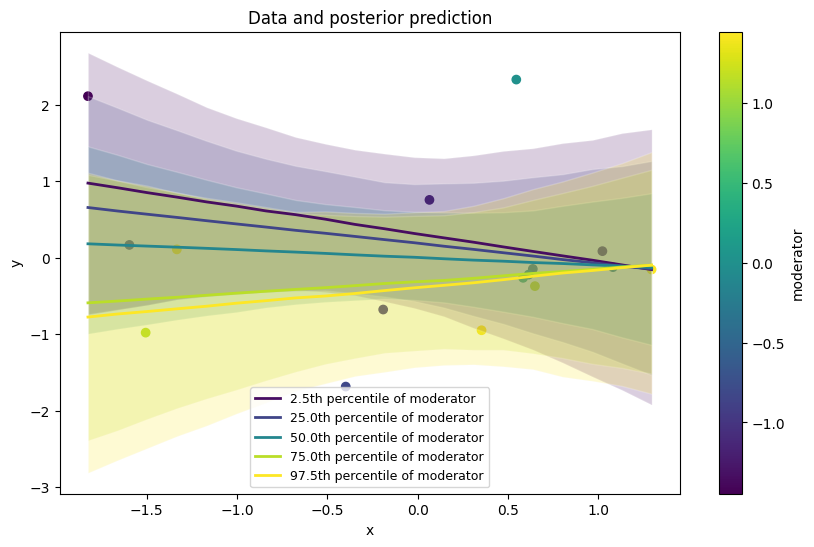

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = plot_data(x, m, y, ax=ax)
posterior_prediction_plot(result, x, m, m_quantiles, ax=ax)
ax.set_title("Data and posterior prediction");

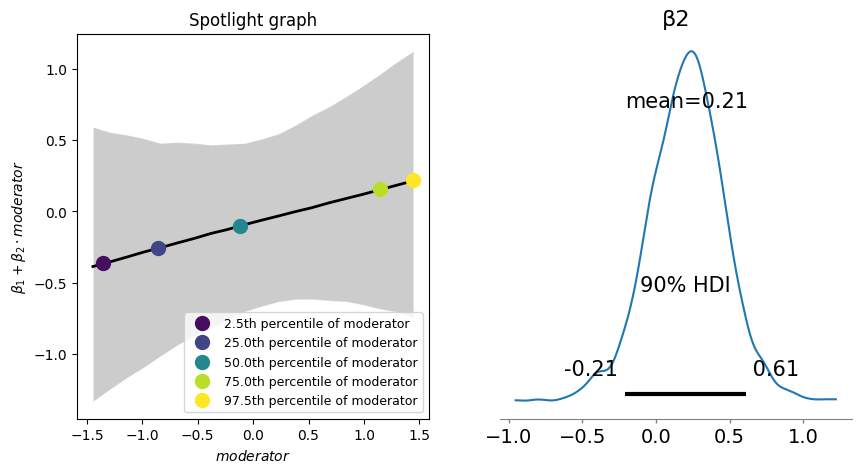

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_moderation_effect(result, m, m_quantiles, ax[0])
az.plot_posterior(result, var_names="β2", ax=ax[1]);